In [7]:
# %%
import inspect, fl_simulation
print(inspect.signature(fl_simulation.run_federated))

# %%
import model
print(model.__file__)
print(hasattr(model, "build_model"))

# %%
# %%
from collections import OrderedDict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score


# %%
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = f"C:/Users/s2/Documents/Federated/dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    # "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    # "malgenome": f"{BASE_DIR}/malgenome.csv",
    # "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}

import model
print(model.__file__)
print(hasattr(model, "build_model"))

(fed_data, name: str, n_features: int, n_classes: int = 2, X_val=None, y_val=None, X_test=None, y_test=None, proximal_mu: float = 0.0, num_rounds: int = 10, local_epochs: int = 10, batch_size: int = 64, lr: float = 0.001) -> Dict[str, List[float]]
c:\Users\s2\Documents\Federated\compared\model.py
True
c:\Users\s2\Documents\Federated\compared\model.py
True


In [8]:

# %%
# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data


def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data


def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data


def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()


def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y



# %%

In [9]:

# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"

data = load_raw(PATHS["drebin"])

if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = pd.to_numeric(
        data[SPECIAL_COLUMN].replace("?", np.nan), errors="coerce"
    )

if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")

data = data.copy()
data[LABEL_COLUMN] = data[LABEL_COLUMN].map({"B": 0, "S": 1})  # pengganti .replace()
data = to_numeric_features(data, LABEL_COLUMN).dropna().reset_index(drop=True)

X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]

report("Drebin", X_drebin, y_drebin)

# %%
from dataset import split_and_prepare_data, make_client_datasets, print_client_distribution

drebin_split = split_and_prepare_data(X_drebin, y_drebin)

clients_iid    = make_client_datasets(drebin_split, n_clients=4, mode="iid")
clients_noniid = make_client_datasets(drebin_split, n_clients=4, mode="non_iid", alpha=0.5)

print_client_distribution(clients_iid, "IID")
print_client_distribution(clients_noniid, "Non-IID (alpha=0.5)")

# val & test tetap global
X_val,  y_val  = drebin_split["X_val_t"],  drebin_split["y_val_t"]
X_test, y_test = drebin_split["X_test_t"], drebin_split["y_test_t"]

# %%
from dataset import make_federated_splits, print_federated_splits

fed_iid    = make_federated_splits(X_drebin, y_drebin, n_clients=4, mode="iid")
fed_noniid = make_federated_splits(X_drebin, y_drebin, n_clients=4, mode="non_iid", alpha=0.5)

print_federated_splits(fed_iid, "IID")
print_federated_splits(fed_noniid, "Non-IID (alpha=0.5)")

# akses data client ke-0
c0 = fed_iid[0]
X_tr, y_tr = c0["X_train"], c0["y_train"]



C:\Users\s2\AppData\Local\Temp\ipykernel_29236\2285318260.py:7: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Train: (10521, 215) | Val: (2255, 215) | Test: (2255, 215)
== IID ==
  Client 0: n=2631 | kelas=[1657, 974]
  Client 1: n=2630 | kelas=[1662, 968]
  Client 2: n=2630 | kelas=[1676, 954]
  Client 3: n=2630 | kelas=[1637, 993]
== Non-IID (alpha=0.5) ==
  Client 0: n=175 | kelas=[123, 52]
  Client 1: n=458 | kelas=[121, 337]
  Client 2: n=2783 | kelas=[263, 2520]
  Client 3: n=7105 | kelas=[6125, 980]
== IID ==
  Client 0: train=2630[1655, 975] | val=564[355, 209] | test=564[355, 209]
  Client 1: train=2630[1653, 977] | val=564[355, 209] | test=564[355, 209]
  Client 2: train=2630[1676, 954] | val=564[360, 204] | test=564[360, 204]
  Client 3: train=2629[1646, 983] | val=564[353, 211] | test=564[353, 211]
== Non-IID (alpha=0.5) ==
  Client 0: train=1319[2, 1317] | val=283[0, 283] | test=283[0, 283]
  Client 1: train=11[9, 2] | val=3[3, 0] | test=3[3, 0]
  Client 2: train=2972[415, 2557] |

INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.05255132541060448, {'accuracy': 0.9831485587583149, 'precision': 0.9794933655006032, 'recall': 0.9747899159663865, 'f1': 0.9771359807460891}, 19.262989599999855)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedAvg-IID] round 01 | loss=0.0526 acc=0.9831 f1=0.9771 | comm=0.487MB (cum 0.487MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.04339554160833359, {'accuracy': 0.9862527716186252, 'precision': 0.983132530120482, 'recall': 0.9795918367346939, 'f1': 0.9813589897775106}, 23.356486499998937)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedAvg-IID] round 02 | loss=0.0434 acc=0.9863 f1=0.9814 | comm=0.487MB (cum 0.975MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (3, 0.03652631491422653, {'accuracy': 0.9875831485587583, 'precision': 0.9820359281437125, 'recall': 0.9843937575030012, 'f1': 0.9832134292565947}, 27.468624299999647)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[FedAvg-NonIID] round 18 | loss=7.5528 acc=0.6652 f1=0.6881 | comm=0.366MB (cum 6.579MB)


INFO :      aggregate_fit: received 3 results and 1 failures
INFO :      fit progress: (19, 8.470331192016602, {'accuracy': 0.6394678492239468, 'precision': 0.5060753341433779, 'recall': 1.0, 'f1': 0.672045179507866}, 41.10537750000003)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedAvg-NonIID] round 19 | loss=8.4703 acc=0.6395 f1=0.6720 | comm=0.366MB (cum 6.945MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (20, 0.41312873363494873, {'accuracy': 0.9534368070953437, 'precision': 0.8965141612200436, 'recall': 0.9879951980792316, 'f1': 0.9400342661336379}, 44.13540130000001)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 44.14s
INFO :      	History (loss, centralized):
INFO :      		round 1: 1.025745153427124
INFO :      		round 2: 1.5626635551452637
INFO :      		round 3: 1.9288910627365112
INFO :      		round 4: 3.238914966583252
INFO :      		round 5: 3.6736233234405518
INFO :      		round 6: 3.945511817932129
INFO :      		round 7: 4.242850303649902
INFO :      		round 8: 4.540243148803711
INFO :      		round 9: 4.669553756713867
INFO :      		round 10: 4.968226909637451
INFO :      		round 11: 5.363044738769531
INFO :      		round 12: 5.236652851104736
INFO :      		round 13: 6.322146892547607
INFO :  

[FedAvg-NonIID] round 20 | loss=0.4131 acc=0.9534 f1=0.9400 | comm=0.487MB (cum 7.432MB)
[FedAvg-NonIID] BANDWIDTH | model=0.061MB up=3.72MB down=3.72MB total=7.43MB (~0.37MB/ronde)


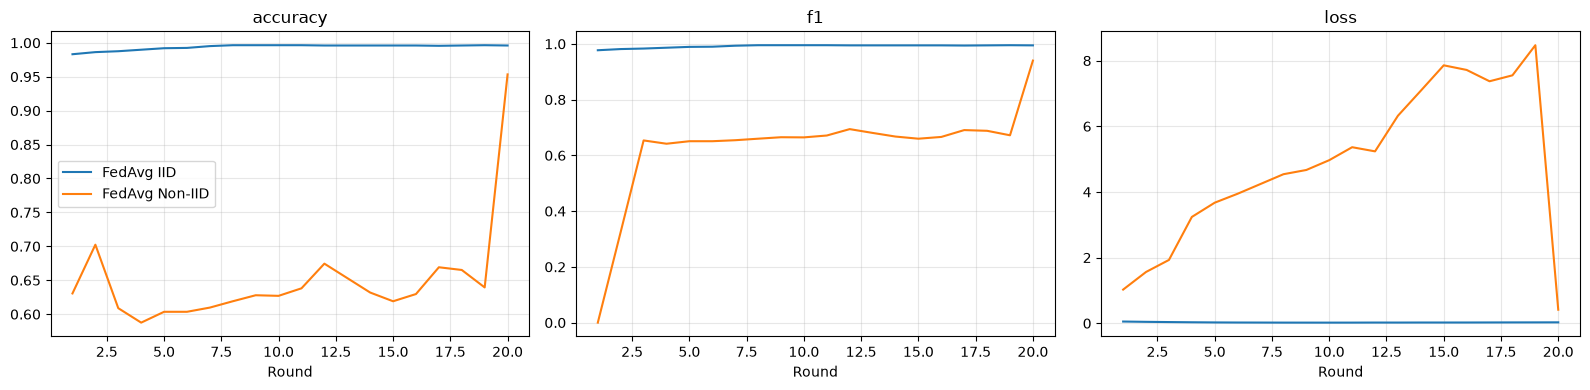

Skenario         |  Val Acc   Val F1 | Test Acc       P       R      F1
FedAvg IID       |   0.9960   0.9946 |   0.9956  0.9952  0.9928  0.9940
FedAvg Non-IID   |   0.9534   0.9400 |   0.9419  0.8718  0.9880  0.9263


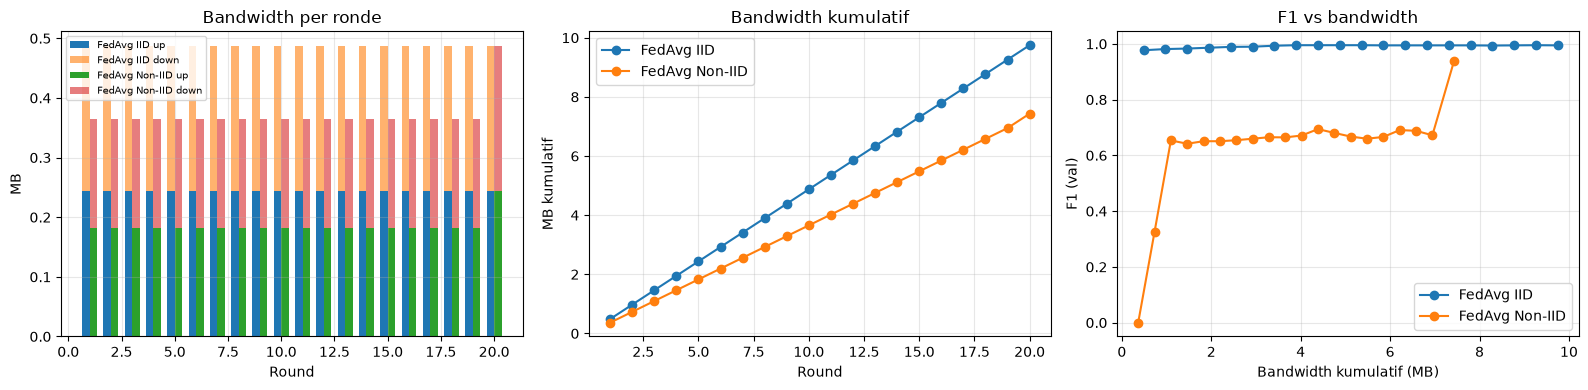

In [10]:

import matplotlib.pyplot as plt
from fl_simulation import run_federated

# Val/test global dari split sebelumnya
COMMON = dict(
    n_features=N_FEATURES,
    n_classes=N_CLASSES,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    num_rounds=20,
    local_epochs=10,
)

# %%
# =============================================================================
# Jalankan: FedAvg IID, FedAvg Non-IID, FedProx Non-IID
# =============================================================================
h_iid    = run_federated(fed_iid,    "FedAvg-IID",     **COMMON)
h_noniid = run_federated(fed_noniid, "FedAvg-NonIID",  **COMMON)
# h_prox   = run_federated(fed_noniid, "FedProx-NonIID", proximal_mu=0.01, **COMMON)

# %%
# =============================================================================
# Visualisasi
# =============================================================================
runs = [("FedAvg IID", h_iid), ("FedAvg Non-IID", h_noniid)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["accuracy", "f1", "loss"]):
    for label, h in runs:
        ax.plot(h["round"], h[metric], label=label)
    ax.set_xlabel("Round")
    ax.set_title(metric)
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

# %%
# =============================================================================
# Ringkasan hasil akhir (validation ronde terakhir & test set)
# =============================================================================
print(f"{'Skenario':16s} | {'Val Acc':>8s} {'Val F1':>8s} | "
      f"{'Test Acc':>8s} {'P':>7s} {'R':>7s} {'F1':>7s}")
for n, h in runs:
    t = h["test"]
    print(f"{n:16s} | {h['accuracy'][-1]:8.4f} {h['f1'][-1]:8.4f} | "
          f"{t['accuracy']:8.4f} {t['precision']:7.4f} "
          f"{t['recall']:7.4f} {t['f1']:7.4f}")

# %%
# =============================================================================
# Visualisasi bandwidth
# =============================================================================
MB = 1024 ** 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) Bandwidth per ronde (uplink vs downlink) untuk tiap skenario
width = 0.35
for i, (label, h) in enumerate(runs):
    xs = [r + (i - 0.5) * width for r in h["round"]]
    axes[0].bar(xs, [b / MB for b in h["bytes_up"]], width,
                label=f"{label} up")
    axes[0].bar(xs, [b / MB for b in h["bytes_down"]], width,
                bottom=[b / MB for b in h["bytes_up"]], label=f"{label} down",
                alpha=0.6)
axes[0].set_xlabel("Round"); axes[0].set_ylabel("MB")
axes[0].set_title("Bandwidth per ronde"); axes[0].legend(fontsize=7)

# (2) Bandwidth kumulatif
for label, h in runs:
    axes[1].plot(h["round"], h["cum_mb"], marker="o", label=label)
axes[1].set_xlabel("Round"); axes[1].set_ylabel("MB kumulatif")
axes[1].set_title("Bandwidth kumulatif"); axes[1].legend()

# (3) F1 vs bandwidth kumulatif
for label, h in runs:
    axes[2].plot(h["cum_mb"], h["f1"], marker="o", label=label)
axes[2].set_xlabel("Bandwidth kumulatif (MB)"); axes[2].set_ylabel("F1 (val)")
axes[2].set_title("F1 vs bandwidth"); axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [11]:
# %%
# =============================================================================
# Ringkasan hasil akhir + bandwidth
# =============================================================================
print(f"{'Skenario':16s} | {'Val Acc':>8s} {'Val F1':>8s} | "
      f"{'Test Acc':>8s} {'P':>7s} {'R':>7s} {'F1':>7s} | "
      f"{'Model MB':>8s} {'Up MB':>8s} {'Down MB':>8s} {'Total MB':>9s}")
for n, h in runs:
    t, c = h["test"], h["comm"]
    print(f"{n:16s} | {h['accuracy'][-1]:8.4f} {h['f1'][-1]:8.4f} | "
          f"{t['accuracy']:8.4f} {t['precision']:7.4f} "
          f"{t['recall']:7.4f} {t['f1']:7.4f} | "
          f"{c['model_size_mb']:8.3f} {c['total_up_mb']:8.2f} "
          f"{c['total_down_mb']:8.2f} {c['total_mb']:9.2f}")

Skenario         |  Val Acc   Val F1 | Test Acc       P       R      F1 | Model MB    Up MB  Down MB  Total MB
FedAvg IID       |   0.9960   0.9946 |   0.9956  0.9952  0.9928  0.9940 |    0.061     4.87     4.87      9.75
FedAvg Non-IID   |   0.9534   0.9400 |   0.9419  0.8718  0.9880  0.9263 |    0.061     3.72     3.72      7.43


In [12]:
# # %%
# import sys
# print(open(r"C:\Users\s2\Documents\FedMal\compared\model.py", encoding="utf-8").read()[:300])
# print("model" in sys.modules)   # True = ada cache lama